In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ipynb.fs.defs.functions import top_bottom_n, top_bottom_n_split, find_outliers_iqr

In [12]:
# Einlesen
df = pd.read_csv("../data/processed/master_2024.csv", sep=",", encoding="UTF-8")
df.columns

Index(['Name', 'Typ', 'ROR', 'erz. Hilfen absolut', 'erz. Hilfen pro 10000',
       '35a Hilfen absolut', '35a Hilfen pro 10000', 'Überörtlicher Träger',
       'Bevölkerung 6 bis 20', 'Anteil Kinder a.d. Gesamtbev.', 'SGB II-Quote',
       'Kinderarztdichte', 'KJP-Dichte'],
      dtype='object')

In [13]:
y_col = "35a Hilfen pro 10000"
x_col = "SGB II-Quote"


print(df[[x_col, y_col]].describe())


       SGB II-Quote  35a Hilfen pro 10000
count     52.000000             52.000000
mean       8.327692            182.865385
std        3.198863             67.057198
min        4.300000             69.000000
25%        5.802500            140.000000
50%        7.795000            170.000000
75%       10.145000            228.500000
max       18.800000            326.000000


In [14]:
print("Korrelation 35a Hilfen zu SGB II-Quote", df[x_col].corr(df[y_col]))

d = df.copy()

d = d[d["Typ"] != "Städteregion"]

corr_by_type = (
    d
    .groupby("Typ")[[x_col, y_col]]
    .corr()
    .iloc[0::2, -1]
)

print(corr_by_type)

Korrelation 35a Hilfen zu SGB II-Quote -0.03257231904755657
Typ                           
Kreis             SGB II-Quote    0.300140
Kreisfreie Stadt  SGB II-Quote   -0.272219
Name: 35a Hilfen pro 10000, dtype: float64


              Name               Typ  SGB II-Quote  35a Hilfen pro 10000
7    Gelsenkirchen  Kreisfreie Stadt         18.80                    77
40  Recklinghausen             Kreis         10.49                   156


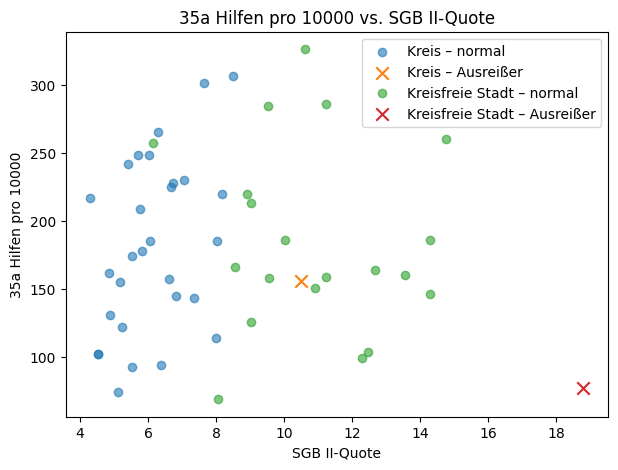

In [15]:
d["outlier_hilfen"] = (
    d.groupby("Typ")[x_col]
      .transform(find_outliers_iqr)
)

d["outlier_armut"] = (
    d.groupby("Typ")[y_col]
      .transform(find_outliers_iqr)
)


d["outlier"] = d["outlier_hilfen"] | d["outlier_armut"]

print(d.loc[d["outlier"], 
              ["Name", "Typ",x_col, y_col]])

plt.figure(figsize=(7, 5))

for typ, g in d.groupby("Typ"):
    # normale Punkte
    plt.scatter(
        g.loc[~g["outlier"], x_col],
        g.loc[~g["outlier"], y_col],
        alpha=0.6,
        label=f"{typ} – normal"
    )
    
    # Ausreißer
    plt.scatter(
        g.loc[g["outlier"], x_col],
        g.loc[g["outlier"], y_col],
        marker="x",
        s=80,
        label=f"{typ} – Ausreißer"
    )

plt.xlabel(x_col)
plt.ylabel(y_col)
plt.legend()
plt.title(f"{y_col} vs. {x_col}")
plt.show()

In [18]:
def run_regression(df_sub, label):
    d = df_sub[["Name",x_col, y_col]].copy()
    X = sm.add_constant(d[x_col])
    y = d[y_col]

    model = sm.OLS(y, X).fit()

    print(f"\n--- {label} ---")
    print(f"n = {len(d)}")
    print(f"b = {model.params[x_col]:.3f}")
    print(f"R² = {model.rsquared:.3f}")
    print(f"p = {model.pvalues[x_col]:.4f}")

    d["y_hat"] = model.predict(X)
    d["residual"] = d[y_col] - d["y_hat"]

    return model, d

df_kreis = d[d["Typ"] == "Kreis"].copy()
df_stadt = d[d["Typ"] == "Kreisfreie Stadt"].copy()

model_kreis, d_kreis = run_regression(df_kreis, "Kreise")
model_stadt, d_stadt = run_regression(df_stadt, "Kreisfreie Städte")


--- Kreise ---
n = 30
b = 13.472
R² = 0.090
p = 0.1071

--- Kreisfreie Städte ---
n = 21
b = -6.727
R² = 0.074
p = 0.2326


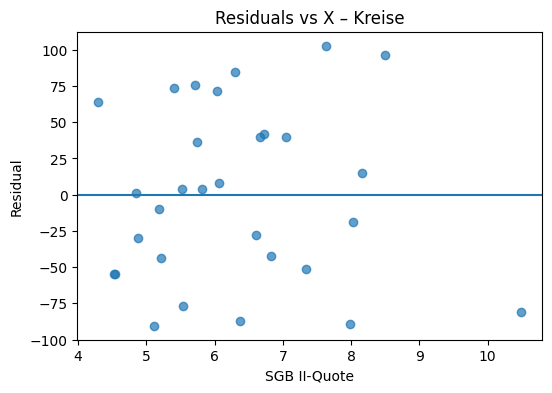

In [19]:
def plot_residuals(d, label):
    plt.figure(figsize=(6,4))
    plt.scatter(d[x_col], d["residual"], alpha=0.7)
    plt.axhline(0)
    plt.xlabel(x_col)
    plt.ylabel("Residual")
    plt.title(f"Residuals vs X – {label}")
    plt.show()

plot_residuals(d_kreis, "Kreise")

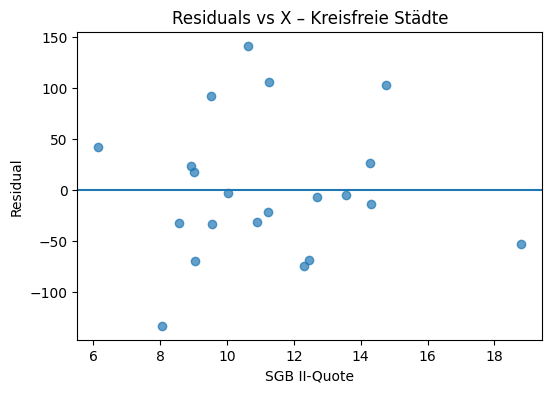

In [20]:
plot_residuals(d_stadt, "Kreisfreie Städte")

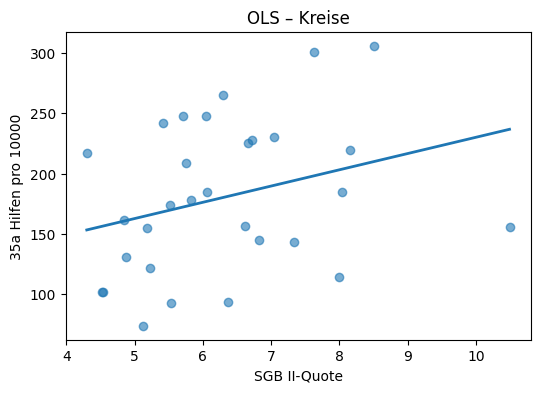

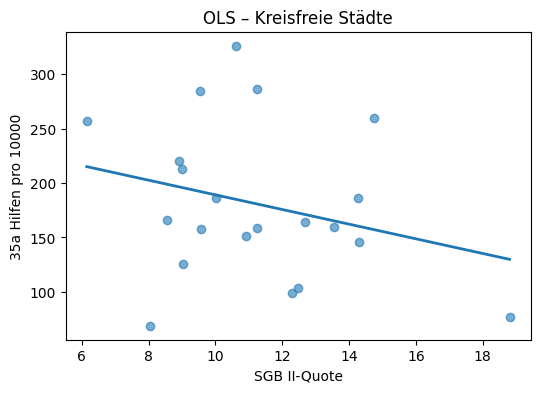

In [21]:
def plot_fit(d, label):
    d_sorted = d.sort_values(x_col)
    plt.figure(figsize=(6,4))
    plt.scatter(d[x_col], d[y_col], alpha=0.6)
    plt.plot(d_sorted[x_col], d_sorted["y_hat"], linewidth=2)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"OLS – {label}")
    plt.show()

plot_fit(d_kreis, "Kreise")
plot_fit(d_stadt, "Kreisfreie Städte")

In [22]:
d_kreis["resid_std"] = (
    d_kreis["residual"] - d_kreis["residual"].mean()
) / d_kreis["residual"].std()

d_stadt["resid_std"] = (
    d_stadt["residual"] - d_stadt["residual"].mean()
) / d_stadt["residual"].std()

print("STD Kreise:", d_kreis["resid_std"])
print("STD Städte:", d_stadt["resid_std"])



STD Kreise: 22   -0.907859
23   -0.910104
24    1.713183
25    1.601148
26   -0.170350
27   -0.729427
28    1.186776
29   -1.454436
30   -0.503045
31    0.020446
32    1.228243
33   -0.705351
34   -0.310309
35   -0.855470
36   -1.484860
37    0.070014
38    1.060786
39    0.132107
40   -1.346183
41    0.700674
42   -0.458156
43    0.069319
44    1.411768
45    0.664141
46    0.601793
47   -1.507105
48    0.243928
49    1.260887
50   -1.284707
51    0.662149
Name: resid_std, dtype: float64
STD Städte: 0    -0.042840
1    -0.469379
2    -0.481246
3    -1.021580
4     1.508316
5     0.376524
6    -1.955331
7    -0.776257
8    -0.075883
9     0.346336
10   -0.208213
11   -0.320461
12    2.068866
13    1.345265
14   -1.005820
15    1.543333
16    0.615717
17   -1.095933
18   -0.499914
19    0.252543
20   -0.104045
Name: resid_std, dtype: float64


In [23]:
cols = ["Name", "SGB II-Quote", "35a Hilfen pro 10000", "residual", "resid_std"]

d_kreis.sort_values("resid_std", ascending=False)[cols].head(5)
d_kreis.sort_values("resid_std")[cols].head(5)


,Name,SGB II-Quote,35a Hilfen pro 10000,residual,resid_std
47,Steinfurt,5.12,74,-90.410953,-1.507105
36,Märkischer Kreis,7.99,114,-89.076502,-1.484860
29,Herford,6.37,94,-87.251349,-1.454436
40,Recklinghausen,10.49,156,-80.757294,-1.346183
50,Warendorf,5.54,93,-77.069326,-1.284707


In [24]:

d_stadt.sort_values("resid_std", ascending=False)[cols].head(5)
d_stadt.sort_values("resid_std")[cols].head(5)


,Name,SGB II-Quote,35a Hilfen pro 10000,residual,resid_std
6,Düsseldorf,8.04,69,-133.307929,-1.955331
17,Oberhausen,12.29,99,-74.717068,-1.095933
3,Bottrop,9.03,126,-69.647940,-1.021580
14,Mönchengladbach,12.46,104,-68.573434,-1.005820
7,Gelsenkirchen,18.80,77,-52.922597,-0.776257
